# Hoàng Phúc - HDBSCAN

Mục tiêu là dùng các feature cấu trúc để phân cụm vật liệu Carbon-24, sau đó dùng `energy` và `relative_energy` để diễn giải ý nghĩa của từng cụm. Hai cột năng lượng không được đưa vào input clustering để tránh rò rỉ thông tin mục tiêu.

## 1. Tổng quan dữ liệu đầu vào

In [9]:
from pathlib import Path
import pandas as pd

FEATURE_FILE = Path("carbon24_features.csv")
feature_df = pd.read_csv(FEATURE_FILE)

schema_summary = pd.DataFrame(
    {
        "column": feature_df.columns,
        "dtype": [str(dtype) for dtype in feature_df.dtypes],
        "missing": feature_df.isna().sum().values,
        "n_unique": feature_df.nunique(dropna=False).values,
    }
)

print("File feature:", FEATURE_FILE.resolve())
print("Kích thước dữ liệu:", feature_df.shape)
print("Số material_id trùng:", feature_df.duplicated(subset=["material_id"]).sum())

display(feature_df.head())
display(feature_df["split"].value_counts().to_frame("n_samples"))
display(feature_df[["energy", "relative_energy"]].describe().T)
display(schema_summary)


File feature: E:\HK2_2025_2026\KTDL\DoAN\carbon24_features.csv
Kích thước dữ liệu: (10153, 32)
Số material_id trùng: 0


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,...,mean_coordination,std_coordination,min_coordination,max_coordination,row_index,split,source_file,material_id,energy,relative_energy
0,C,C,6,2.48053,5.09056,4.89497,57.97521,59.51109,43.04559,34.994539,...,4.0,0.0,4.0,4.0,0,train,huggingface,C-130499-1826-36,-154.311891,0.245094
1,C,C,10,2.48986,4.65679,5.94592,90.03290,77.93642,57.67568,56.442646,...,4.0,0.0,4.0,4.0,1,train,huggingface,C-13904-4247-31,-154.332183,0.224802
2,C,C,10,2.44168,4.79849,5.95909,119.73602,101.56104,75.51457,58.455462,...,3.8,0.4,3.0,4.0,2,train,huggingface,C-92138-4782-35,-154.178157,0.378828
3,C,C,20,2.47518,4.18933,11.18377,100.54005,77.38712,89.87842,111.153317,...,4.0,0.0,4.0,4.0,3,train,huggingface,C-192672-505-73,-154.309339,0.247646
4,C,C,6,3.39500,4.81978,3.65211,112.26885,128.35152,77.74360,43.348062,...,3.0,0.0,3.0,3.0,4,train,huggingface,C-193956-5355-22,-154.141835,0.415150


,n_samples
split,
train,6091
validation,2032
test,2030


,count,mean,std,min,25%,50%,75%,max
energy,10153.0,-154.250522,0.1365,-154.556985,-154.333489,-154.217487,-154.136999,-154.065602
relative_energy,10153.0,0.306463,0.1365,0.000000,0.223496,0.339498,0.419986,0.491383


,column,dtype,missing,n_unique
0,formula,object,0,1
1,elements,object,0,1
2,num_atoms,int64,0,10
3,a,float64,0,7854
4,b,float64,0,9724
5,c,float64,0,9872
6,alpha,float64,0,10126
7,beta,float64,0,9968
8,gamma,float64,0,9860
9,volume,float64,0,10153


## 2. Chạy HDBSCAN pipeline trực tiếp trong notebook

Cell bên dưới chứa toàn bộ pipeline HDBSCAN: đọc `carbon24_features.csv`, chuẩn hóa schema, chọn feature cấu trúc phù hợp, impute bằng median, loại feature số tương quan quá cao, mã hóa `crystal_system`, chuẩn hóa bằng `StandardScaler`, grid search tham số HDBSCAN, chọn mô hình tốt nhất, gán nhãn cụm, tính membership probability, phân tích noise/outlier và vẽ hình.

In [10]:
from pathlib import Path
import sys
import warnings

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

try:
    import hdbscan
except ImportError as exc:
    raise SystemExit(
        "Thiếu thư viện hdbscan. Cài trong môi trường notebook bằng:\n"
        "  pip install hdbscan\n"
        "Sau đó chạy lại notebook."
    ) from exc


RANDOM_STATE = 42
MAX_ACCEPTABLE_NOISE_RATIO = 0.30
MIN_CLUSTER_SIZE_GRID = [10, 20, 30, 50, 80, 100]
MIN_SAMPLES_GRID = [3, 5, 10, 15]
CORRELATION_THRESHOLD = 0.98

PROJECT_DIR = Path.cwd()
COMBINE_DIR = PROJECT_DIR / "Combine_Dataset"

# File feature đúng cho notebook này là file 32 cột nằm ở thư mục gốc DoAN.
FEATURES_PATH = PROJECT_DIR / "carbon24_features.csv"
OUTPUT_DIR = COMBINE_DIR / "hdbscan_phuc"
FIGURE_DIR = OUTPUT_DIR / "figures"

SEARCH_PATH = OUTPUT_DIR / "hdbscan_grid_search.csv"
RESULTS_PATH = OUTPUT_DIR / "hdbscan_results.csv"
NOISE_PATH = OUTPUT_DIR / "hdbscan_noise_outliers.csv"
PROFILE_PATH = OUTPUT_DIR / "hdbscan_cluster_profile.csv"
ENERGY_SUMMARY_PATH = OUTPUT_DIR / "hdbscan_energy_summary.csv"

# Chỉ dùng feature mô tả cấu trúc/hình học cho clustering.
# Không đưa energy, relative_energy, split, material_id, source_file vào input.
NUMERIC_CLUSTER_FEATURES = [
    "num_atoms",
    "a",
    "b",
    "c",
    "alpha",
    "beta",
    "gamma",
    "volume",
    "volume_per_atom",
    "density",
    "b_over_a",
    "c_over_a",
    "angle_deviation",
    "mean_bond_length",
    "std_bond_length",
    "min_bond_length",
    "max_bond_length",
    "mean_coordination",
    "std_coordination",
    "min_coordination",
    "max_coordination",
]

# `crystal_system` là categorical compact và có ý nghĩa tinh thể học rõ ràng.
# Không dùng trực tiếp `space_group_number` như biến số liên tục vì khoảng cách
# giữa các mã space group không phải khoảng cách hình học thật.
CATEGORICAL_CLUSTER_FEATURES = ["crystal_system"]

RESULT_ID_COLUMNS = [
    "row_index",
    "material_id",
    "split",
    "source_file",
    "formula",
    "elements",
    "space_group_number",
    "space_group_symbol",
    "crystal_system",
    "energy",
    "energy_per_atom",
    "relative_energy",
]


def ensure_output_dirs() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def load_features() -> pd.DataFrame:
    if not FEATURES_PATH.exists():
        raise FileNotFoundError(f"Không tìm thấy file feature: {FEATURES_PATH}")

    df = pd.read_csv(FEATURES_PATH)

    if "energy_per_atom" not in df.columns and "energy" in df.columns:
        # Trong file root, cột energy đang có cùng ý nghĩa với energy_per_atom
        # của pipeline cũ, nên tạo alias để các bước diễn giải phía sau thống nhất.
        df["energy_per_atom"] = df["energy"]

    required_cols = set(NUMERIC_CLUSTER_FEATURES + CATEGORICAL_CLUSTER_FEATURES)
    required_cols.update(["material_id", "energy_per_atom", "relative_energy"])
    missing_cols = sorted(col for col in required_cols if col not in df.columns)
    if missing_cols:
        raise ValueError(f"carbon24_features.csv thiếu các cột bắt buộc: {missing_cols}")

    return df


def drop_highly_correlated_features(data: pd.DataFrame, threshold: float = CORRELATION_THRESHOLD) -> tuple[list[str], list[str]]:
    corr = data.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    kept = [column for column in data.columns if column not in to_drop]
    return kept, to_drop


def build_preprocessed_matrix(df: pd.DataFrame) -> tuple[np.ndarray, list[str], list[str]]:
    x_numeric_raw = df[NUMERIC_CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)

    imputer = SimpleImputer(strategy="median")
    x_numeric_imputed = pd.DataFrame(
        imputer.fit_transform(x_numeric_raw),
        columns=NUMERIC_CLUSTER_FEATURES,
        index=df.index,
    )
    selected_numeric_cols, dropped_numeric_cols = drop_highly_correlated_features(x_numeric_imputed)

    scaler = StandardScaler()
    x_numeric_scaled = pd.DataFrame(
        scaler.fit_transform(x_numeric_imputed[selected_numeric_cols]),
        columns=selected_numeric_cols,
        index=df.index,
    )

    categorical_encoded = pd.get_dummies(
        df[CATEGORICAL_CLUSTER_FEATURES].fillna("unknown").astype(str),
        columns=CATEGORICAL_CLUSTER_FEATURES,
        prefix=CATEGORICAL_CLUSTER_FEATURES,
        dtype=float,
    )

    x_final = pd.concat([x_numeric_scaled, categorical_encoded], axis=1)
    selected_cols = list(x_final.columns)
    dropped_cols = dropped_numeric_cols
    return x_final.to_numpy(dtype=float), selected_cols, dropped_cols


def evaluate_hdbscan(labels: np.ndarray, x_values: np.ndarray) -> dict:
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    cluster_labels = sorted(label for label in set(labels) if label != -1)
    n_clusters = len(cluster_labels)
    n_noise = int(np.sum(~non_noise_mask))
    noise_ratio = n_noise / len(labels)

    silhouette = np.nan
    n_non_noise = int(np.sum(non_noise_mask))
    if n_clusters >= 2 and n_non_noise > n_clusters:
        non_noise_labels = labels[non_noise_mask]
        if len(set(non_noise_labels)) >= 2:
            silhouette = silhouette_score(x_values[non_noise_mask], non_noise_labels)

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_ratio": noise_ratio,
        "silhouette_without_noise": silhouette,
    }


def run_grid_search(x_scaled: np.ndarray) -> pd.DataFrame:
    rows = []
    for min_cluster_size in MIN_CLUSTER_SIZE_GRID:
        for min_samples in MIN_SAMPLES_GRID:
            model = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric="euclidean",
                cluster_selection_method="eom",
                prediction_data=True,
            )
            labels = model.fit_predict(x_scaled)
            row = evaluate_hdbscan(labels, x_scaled)
            row.update(
                {
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                }
            )
            rows.append(row)
    return pd.DataFrame(rows)


def choose_best_config(search_df: pd.DataFrame) -> pd.Series:
    valid = search_df[
        (search_df["n_clusters"] >= 2)
        & (search_df["noise_ratio"] <= MAX_ACCEPTABLE_NOISE_RATIO)
    ].dropna(subset=["silhouette_without_noise"])

    if len(valid) > 0:
        ranked = valid.sort_values(
            ["silhouette_without_noise", "noise_ratio", "n_clusters"],
            ascending=[False, True, False],
        )
        return ranked.iloc[0]

    fallback = search_df[search_df["n_clusters"] >= 2].dropna(subset=["silhouette_without_noise"])
    if len(fallback) > 0:
        ranked = fallback.sort_values(
            ["silhouette_without_noise", "noise_ratio"],
            ascending=[False, True],
        )
        return ranked.iloc[0]

    return search_df.sort_values(["noise_ratio", "n_clusters"], ascending=[True, False]).iloc[0]


def fit_final_hdbscan(x_scaled: np.ndarray, best_row: pd.Series):
    model = hdbscan.HDBSCAN(
        min_cluster_size=int(best_row["min_cluster_size"]),
        min_samples=int(best_row["min_samples"]),
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    labels = model.fit_predict(x_scaled)
    probabilities = model.probabilities_
    return model, labels, probabilities


def mode_value(series: pd.Series):
    mode = series.dropna().mode()
    return mode.iloc[0] if len(mode) else np.nan


def build_result_tables(
    df: pd.DataFrame,
    x_scaled: np.ndarray,
    labels: np.ndarray,
    probabilities: np.ndarray,
    selected_cols: list[str],
    dropped_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_2d = pca.fit_transform(x_scaled)

    result_cols = [col for col in RESULT_ID_COLUMNS if col in df.columns]
    results = df[result_cols].copy()
    results["hdbscan_cluster"] = labels
    results["hdbscan_probability"] = probabilities
    results["hdbscan_is_noise"] = labels == -1
    results["pca1"] = pca_2d[:, 0]
    results["pca2"] = pca_2d[:, 1]

    noise = results[results["hdbscan_cluster"] == -1].copy()

    profile_cols = {
        "n_samples": ("hdbscan_cluster", "size"),
        "probability_mean": ("hdbscan_probability", "mean"),
        "probability_median": ("hdbscan_probability", "median"),
        "energy_mean": ("energy_per_atom", "mean"),
        "energy_std": ("energy_per_atom", "std"),
        "energy_min": ("energy_per_atom", "min"),
        "energy_max": ("energy_per_atom", "max"),
        "relative_energy_mean": ("relative_energy", "mean"),
        "relative_energy_std": ("relative_energy", "std"),
    }

    if "crystal_system" in results.columns:
        profile_cols["dominant_crystal_system"] = ("crystal_system", mode_value)
        profile_cols["num_crystal_systems"] = ("crystal_system", "nunique")
    if "space_group_symbol" in results.columns:
        profile_cols["dominant_space_group_symbol"] = ("space_group_symbol", mode_value)
        profile_cols["num_space_groups"] = ("space_group_symbol", "nunique")
    if "space_group_number" in results.columns:
        profile_cols["dominant_space_group_number"] = ("space_group_number", mode_value)

    profile = results.groupby("hdbscan_cluster").agg(**profile_cols).reset_index()
    profile["is_noise_cluster"] = profile["hdbscan_cluster"] == -1
    profile["selected_features"] = ", ".join(selected_cols)
    profile["dropped_correlated_numeric_features"] = ", ".join(dropped_cols)
    return results, noise, profile


def save_plots(results: pd.DataFrame) -> None:
    plot_df = results.copy()
    plot_df["cluster_label"] = plot_df["hdbscan_cluster"].astype(str)
    plot_df.loc[plot_df["hdbscan_cluster"] == -1, "cluster_label"] = "noise"

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x="pca1",
        y="pca2",
        hue="cluster_label",
        style="hdbscan_is_noise",
        s=35,
        linewidth=0,
        alpha=0.85,
    )
    plt.title("Cụm HDBSCAN trên không gian PCA 2D")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Cụm", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "hdbscan_pca_clusters.png", dpi=220)
    plt.close()

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        plot_df["pca1"],
        plot_df["pca2"],
        c=plot_df["hdbscan_probability"],
        cmap="viridis",
        s=35,
        alpha=0.85,
        linewidths=0,
    )
    plt.colorbar(scatter, label="Membership probability")
    plt.title("Membership probability của HDBSCAN trên PCA 2D")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "hdbscan_membership_probability.png", dpi=220)
    plt.close()

    order = sorted(plot_df["hdbscan_cluster"].unique())
    plt.figure(figsize=(11, 6))
    sns.boxplot(
        data=plot_df,
        x="hdbscan_cluster",
        y="energy_per_atom",
        order=order,
        color="#9ecae1",
        fliersize=2,
    )
    plt.title("Energy per atom theo cụm HDBSCAN và noise")
    plt.xlabel("Cụm HDBSCAN (-1 = noise)")
    plt.ylabel("Energy per atom")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "hdbscan_energy_boxplot.png", dpi=220)
    plt.close()


def main() -> None:
    warnings.filterwarnings("ignore", category=FutureWarning)
    ensure_output_dirs()

    df = load_features()
    x_scaled, selected_cols, dropped_cols = build_preprocessed_matrix(df)

    search_df = run_grid_search(x_scaled)
    best_row = choose_best_config(search_df)
    search_df["selected_best"] = (
        (search_df["min_cluster_size"] == int(best_row["min_cluster_size"]))
        & (search_df["min_samples"] == int(best_row["min_samples"]))
    )
    search_df.to_csv(SEARCH_PATH, index=False)

    _, labels, probabilities = fit_final_hdbscan(x_scaled, best_row)
    final_metrics = evaluate_hdbscan(labels, x_scaled)
    results, noise, profile = build_result_tables(
        df,
        x_scaled,
        labels,
        probabilities,
        selected_cols,
        dropped_cols,
    )

    results.to_csv(RESULTS_PATH, index=False)
    noise.to_csv(NOISE_PATH, index=False)
    profile.to_csv(PROFILE_PATH, index=False)
    profile[
        [
            "hdbscan_cluster",
            "is_noise_cluster",
            "n_samples",
            "energy_mean",
            "energy_std",
            "energy_min",
            "energy_max",
            "relative_energy_mean",
            "probability_mean",
            "dominant_crystal_system",
            "dominant_space_group_symbol",
        ]
    ].to_csv(ENERGY_SUMMARY_PATH, index=False)

    save_plots(results)

    print("Đã hoàn tất grid search HDBSCAN.")
    print(f"File feature đầu vào: {FEATURES_PATH}")
    print(f"Kích thước dữ liệu: {df.shape}")
    print(f"Feature dùng cho clustering ({len(selected_cols)}): {selected_cols}")
    print(f"Feature số bị loại do tương quan cao: {dropped_cols}")
    print("Cấu hình tốt nhất:")
    print(best_row.to_string())
    print("Metric cuối cùng:")
    print(pd.Series(final_metrics).to_string())
    print(f"Đã lưu grid search: {SEARCH_PATH}")
    print(f"Đã lưu label/probability cuối cùng: {RESULTS_PATH}")
    print(f"Đã lưu noise/outlier: {NOISE_PATH}")
    print(f"Đã lưu cluster profile: {PROFILE_PATH}")
    print(f"Đã lưu hình: {FIGURE_DIR}")


# Chạy pipeline trực tiếp trong notebook.
main()


Đã hoàn tất grid search HDBSCAN.
File feature đầu vào: e:\HK2_2025_2026\KTDL\DoAN\carbon24_features.csv
Kích thước dữ liệu: (10153, 33)
Feature dùng cho clustering (26): ['num_atoms', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'volume', 'volume_per_atom', 'b_over_a', 'c_over_a', 'angle_deviation', 'mean_bond_length', 'std_bond_length', 'min_bond_length', 'max_bond_length', 'std_coordination', 'min_coordination', 'max_coordination', 'crystal_system_cubic', 'crystal_system_hexagonal', 'crystal_system_monoclinic', 'crystal_system_orthorhombic', 'crystal_system_tetragonal', 'crystal_system_triclinic', 'crystal_system_trigonal']
Feature số bị loại do tương quan cao: ['density', 'mean_coordination']
Cấu hình tốt nhất:
n_clusters                    3.000000
n_noise                     786.000000
noise_ratio                   0.077416
silhouette_without_noise      0.278758
min_cluster_size            100.000000
min_samples                  15.000000
Metric cuối cùng:
n_clusters                  

## 3. Bảng grid search

Silhouette được tính sau khi loại các mẫu noise có label `-1`, vì các điểm noise không đại diện cho cấu trúc cụm ổn định.

In [11]:
import pandas as pd

search_df = pd.read_csv('Combine_Dataset/hdbscan_phuc/hdbscan_grid_search.csv')
search_df.sort_values(
    ['selected_best', 'silhouette_without_noise', 'noise_ratio'],
    ascending=[False, False, True]
).head(24)

,n_clusters,n_noise,noise_ratio,silhouette_without_noise,min_cluster_size,min_samples,selected_best
23,3,786,0.077416,0.278758,100,15,True
0,222,5250,0.517089,0.407845,10,3,False
2,114,4988,0.491283,0.346193,10,10,False
3,74,5546,0.546242,0.337332,10,15,False
1,154,4282,0.421747,0.310369,10,5,False
7,52,5585,0.550084,0.293294,20,15,False
11,31,5837,0.574904,0.276308,30,15,False
22,3,532,0.052398,0.273330,100,10,False
21,3,279,0.027480,0.267852,100,5,False
20,3,184,0.018123,0.265465,100,3,False


## 4. Kết quả cụm và xác suất membership

In [12]:
results_df = pd.read_csv('Combine_Dataset/hdbscan_phuc/hdbscan_results.csv')
display(results_df.head())
display(results_df['hdbscan_cluster'].value_counts().sort_index().to_frame('n_samples'))
display(results_df['hdbscan_probability'].describe().to_frame().T)

,row_index,material_id,split,source_file,formula,elements,space_group_number,space_group_symbol,crystal_system,energy,energy_per_atom,relative_energy,hdbscan_cluster,hdbscan_probability,hdbscan_is_noise,pca1,pca2
0,0,C-130499-1826-36,train,huggingface,C,C,12,C2/m,monoclinic,-154.311891,-154.311891,0.245094,1,0.944592,False,-1.526489,2.212702
1,1,C-13904-4247-31,train,huggingface,C,C,12,C2/m,monoclinic,-154.332183,-154.332183,0.224802,1,1.000000,False,0.164196,2.080668
2,2,C-92138-4782-35,train,huggingface,C,C,8,Cm,monoclinic,-154.178157,-154.178157,0.378828,2,0.890276,False,0.799185,0.766559
3,3,C-192672-505-73,train,huggingface,C,C,1,P1,triclinic,-154.309339,-154.309339,0.247646,-1,0.000000,True,3.577657,1.701084
4,4,C-193956-5355-22,train,huggingface,C,C,12,C2/m,monoclinic,-154.141835,-154.141835,0.415150,0,0.662767,False,-2.575856,-2.944766


,n_samples
hdbscan_cluster,
-1,786
0,2201
1,3250
2,3916


,count,mean,std,min,25%,50%,75%,max
hdbscan_probability,10153.0,0.866841,0.267649,0.0,0.860512,1.0,1.0,1.0


## 5. Noise/outlier

In [13]:
noise_df = pd.read_csv('Combine_Dataset/hdbscan_phuc/hdbscan_noise_outliers.csv')
print('Số mẫu noise:', len(noise_df))
print('Tỷ lệ noise:', len(noise_df) / len(results_df))
display(noise_df.head(20))

Số mẫu noise: 786
Tỷ lệ noise: 0.0774155422042746


,row_index,material_id,split,source_file,formula,elements,space_group_number,space_group_symbol,crystal_system,energy,energy_per_atom,relative_energy,hdbscan_cluster,hdbscan_probability,hdbscan_is_noise,pca1,pca2
0,3,C-192672-505-73,train,huggingface,C,C,1,P1,triclinic,-154.309339,-154.309339,0.247646,-1,0.0,True,3.577657,1.701084
1,5,C-176661-8591-28,train,huggingface,C,C,12,C2/m,monoclinic,-154.197943,-154.197943,0.359042,-1,0.0,True,1.806116,-0.370412
2,11,C-170888-2365-32,train,huggingface,C,C,1,P1,triclinic,-154.112675,-154.112675,0.444310,-1,0.0,True,1.711608,0.660873
3,24,C-142789-7601-3,train,huggingface,C,C,74,Imma,orthorhombic,-154.125035,-154.125035,0.431950,-1,0.0,True,1.025112,1.323895
4,83,C-141043-2496-23,train,huggingface,C,C,12,C2/m,monoclinic,-154.217487,-154.217487,0.339498,-1,0.0,True,0.520412,0.099964
5,87,C-172941-6659-36,train,huggingface,C,C,63,Cmcm,orthorhombic,-154.296563,-154.296563,0.260422,-1,0.0,True,0.535206,-1.247512
6,124,C-136387-2750-21,train,huggingface,C,C,8,Cm,monoclinic,-154.211338,-154.211338,0.345647,-1,0.0,True,4.357518,1.155860
7,138,C-134216-4713-46,train,huggingface,C,C,65,Cmmm,orthorhombic,-154.154943,-154.154943,0.402042,-1,0.0,True,3.423217,0.248261
8,148,C-137379-9907-58,train,huggingface,C,C,1,P1,triclinic,-154.318756,-154.318756,0.238229,-1,0.0,True,2.933284,1.551659
9,153,C-130532-5775-1,train,huggingface,C,C,229,Im-3m,cubic,-154.082461,-154.082461,0.474524,-1,0.0,True,-3.571901,1.436047


## 6. Trực quan PCA cho HDBSCAN

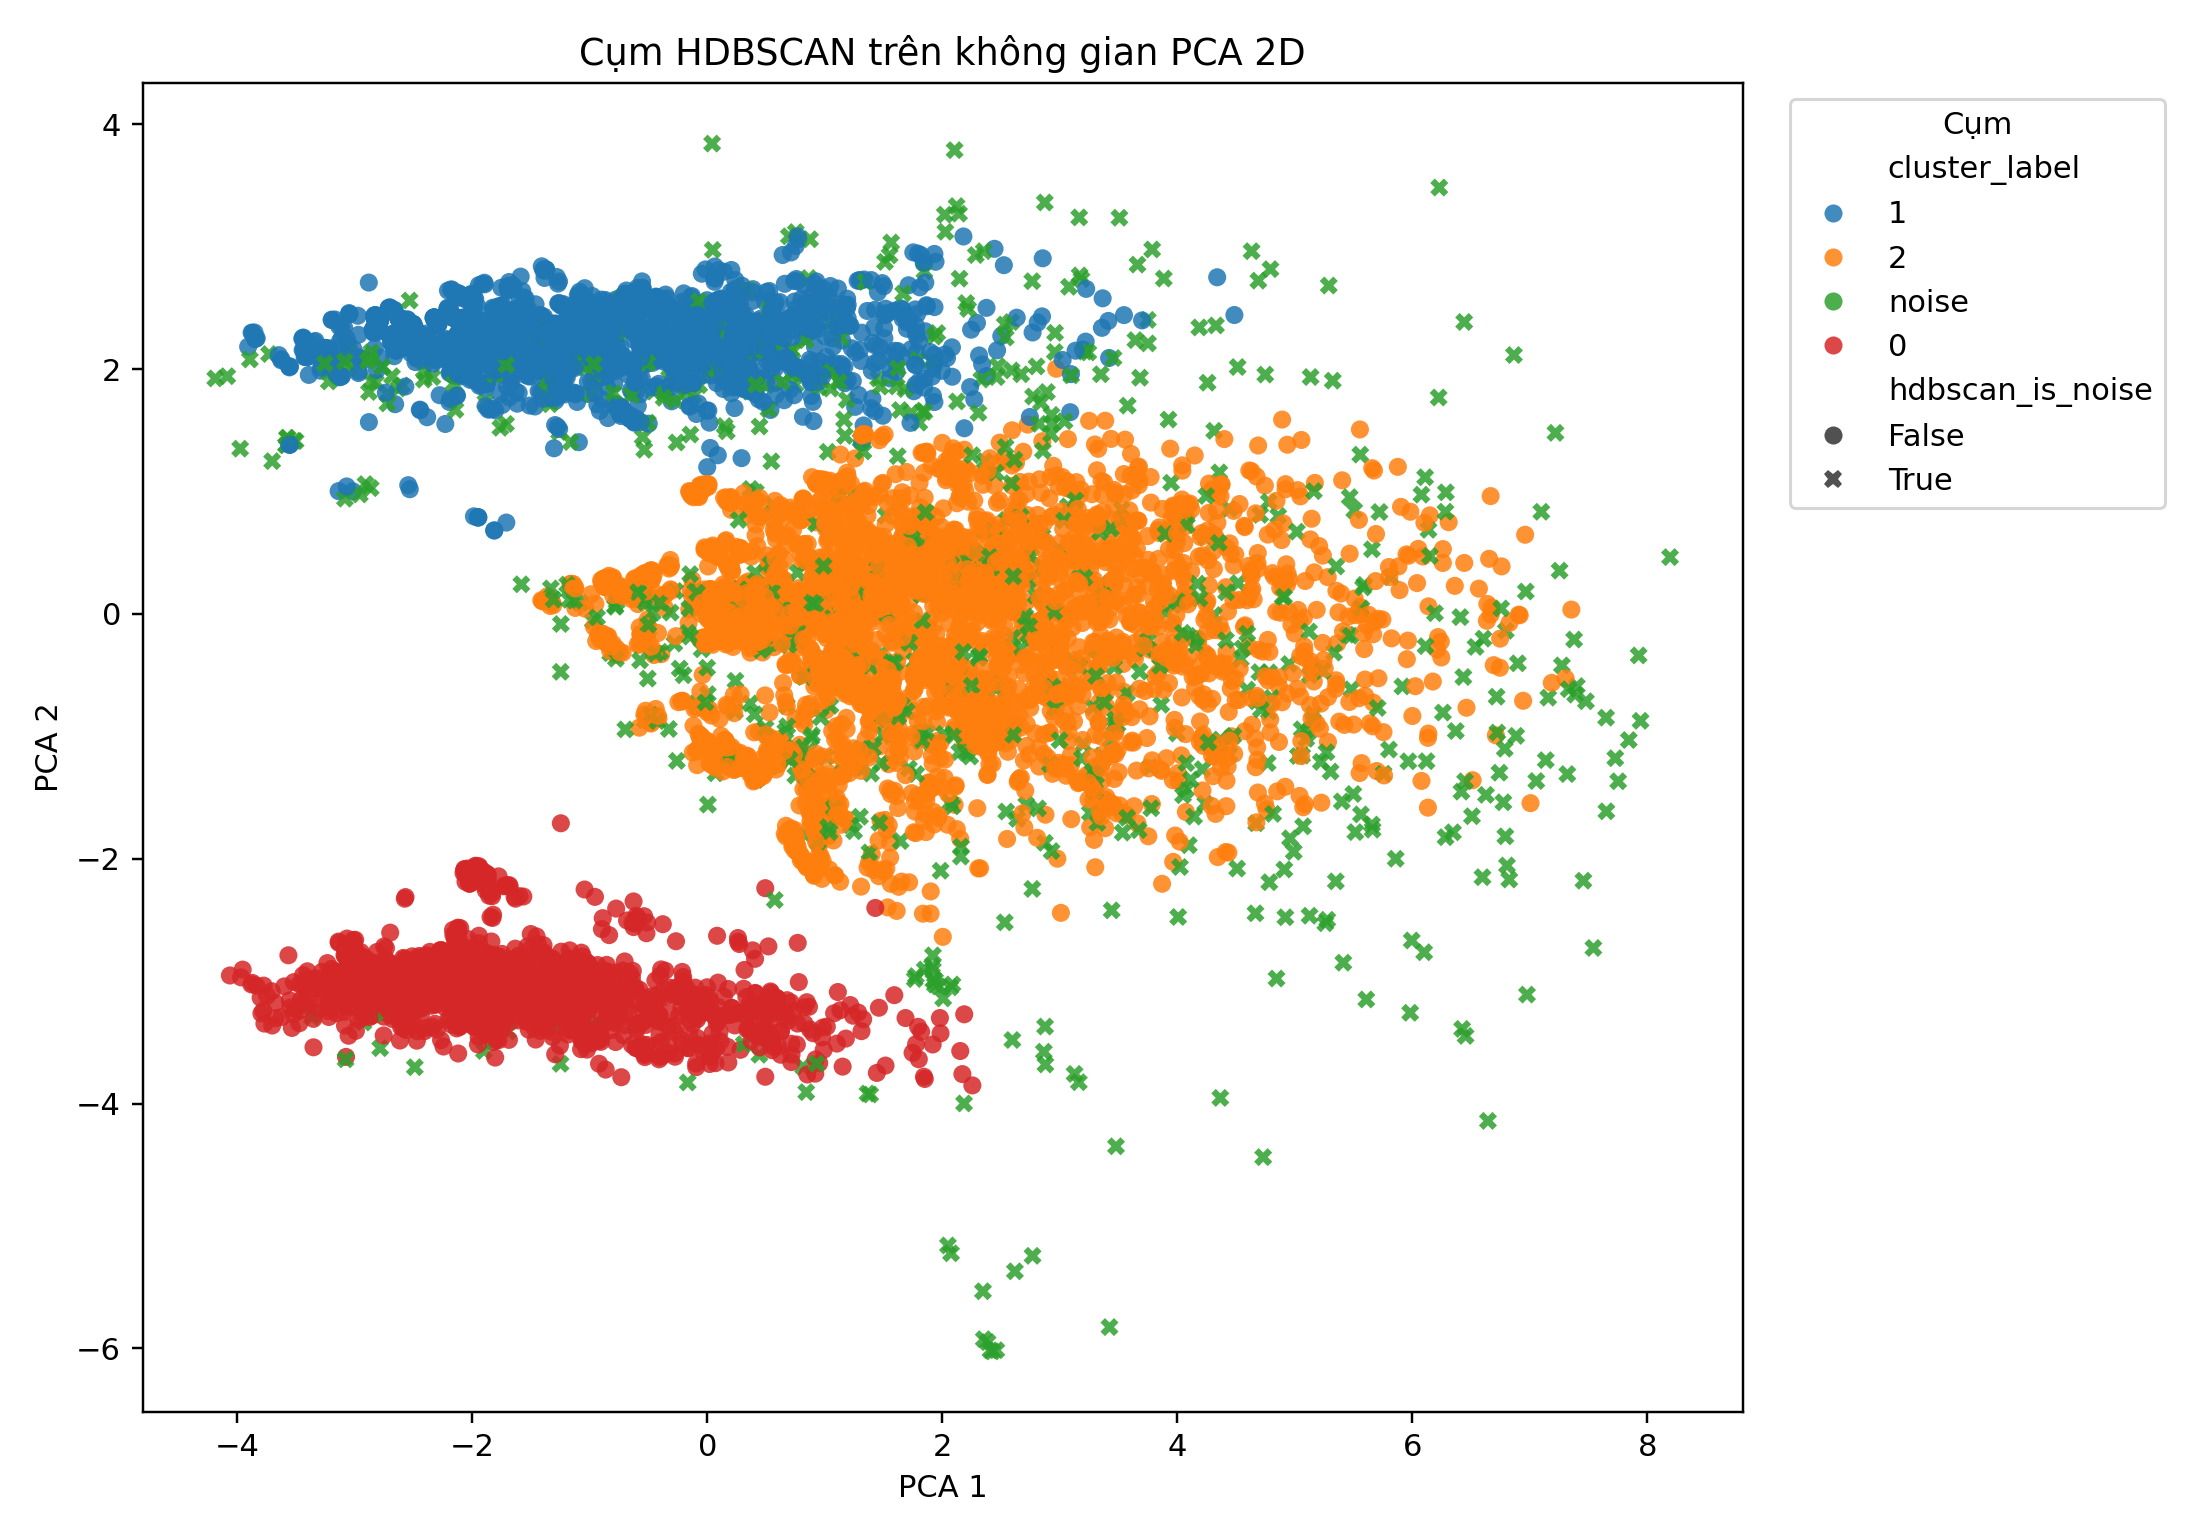

In [14]:
from IPython.display import Image, display

display(Image(filename='Combine_Dataset/hdbscan_phuc/figures/hdbscan_pca_clusters.png'))

## 7. Trực quan membership probability của HDBSCAN

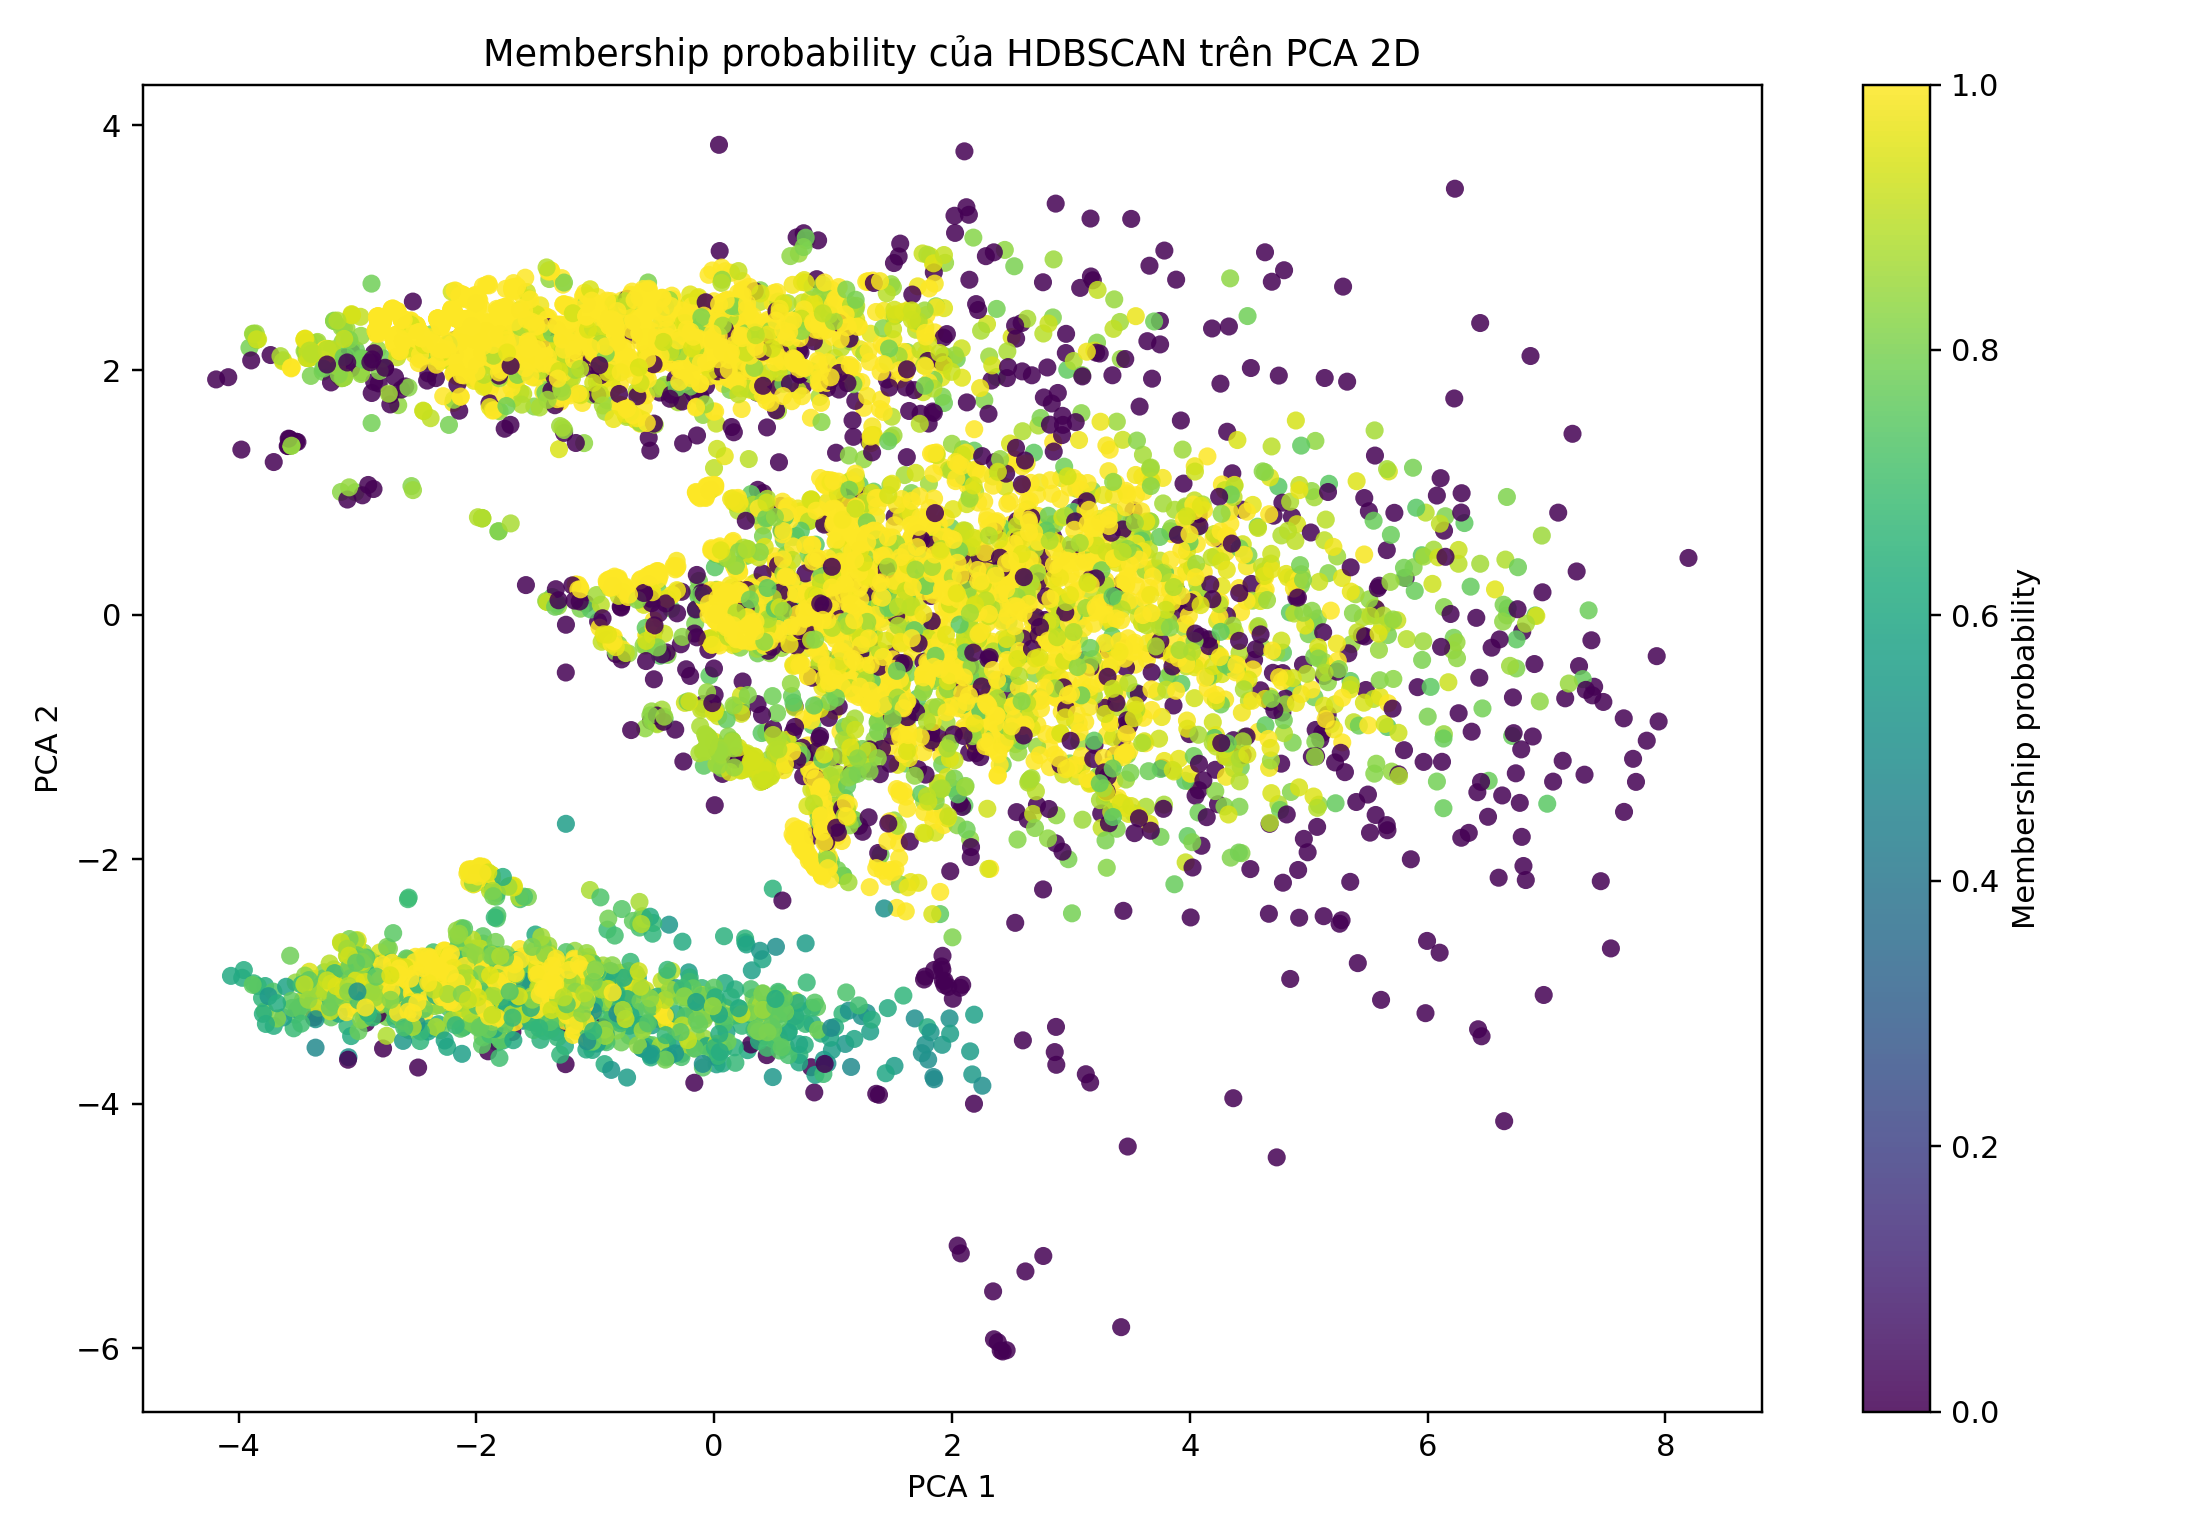

In [15]:
display(Image(filename='Combine_Dataset/hdbscan_phuc/figures/hdbscan_membership_probability.png'))

## 8. Phân bố năng lượng theo cụm HDBSCAN

,hdbscan_cluster,n_samples,probability_mean,probability_median,energy_mean,energy_std,energy_min,energy_max,relative_energy_mean,relative_energy_std,dominant_crystal_system,num_crystal_systems,dominant_space_group_symbol,num_space_groups,dominant_space_group_number,is_noise_cluster,selected_features,dropped_correlated_numeric_features
0,-1,786,0.000000,0.0000,-154.182677,0.107673,-154.550003,-154.066488,0.374308,0.107673,triclinic,7,P1,41,1,True,"num_atoms, a, b, c, alpha, beta, gamma, volume...","density, mean_coordination"
1,0,2201,0.873813,0.9155,-154.302434,0.157380,-154.486840,-154.065702,0.254551,0.157380,triclinic,5,P-1,19,2,False,"num_atoms, a, b, c, alpha, beta, gamma, volume...","density, mean_coordination"
2,1,3250,0.976444,1.0000,-154.316697,0.138527,-154.556985,-154.065784,0.240288,0.138527,monoclinic,7,C2/m,42,12,False,"num_atoms, a, b, c, alpha, beta, gamma, volume...","density, mean_coordination"
3,2,3916,0.945947,1.0000,-154.180043,0.071440,-154.380496,-154.065602,0.376942,0.071440,monoclinic,4,C2/m,28,12,False,"num_atoms, a, b, c, alpha, beta, gamma, volume...","density, mean_coordination"


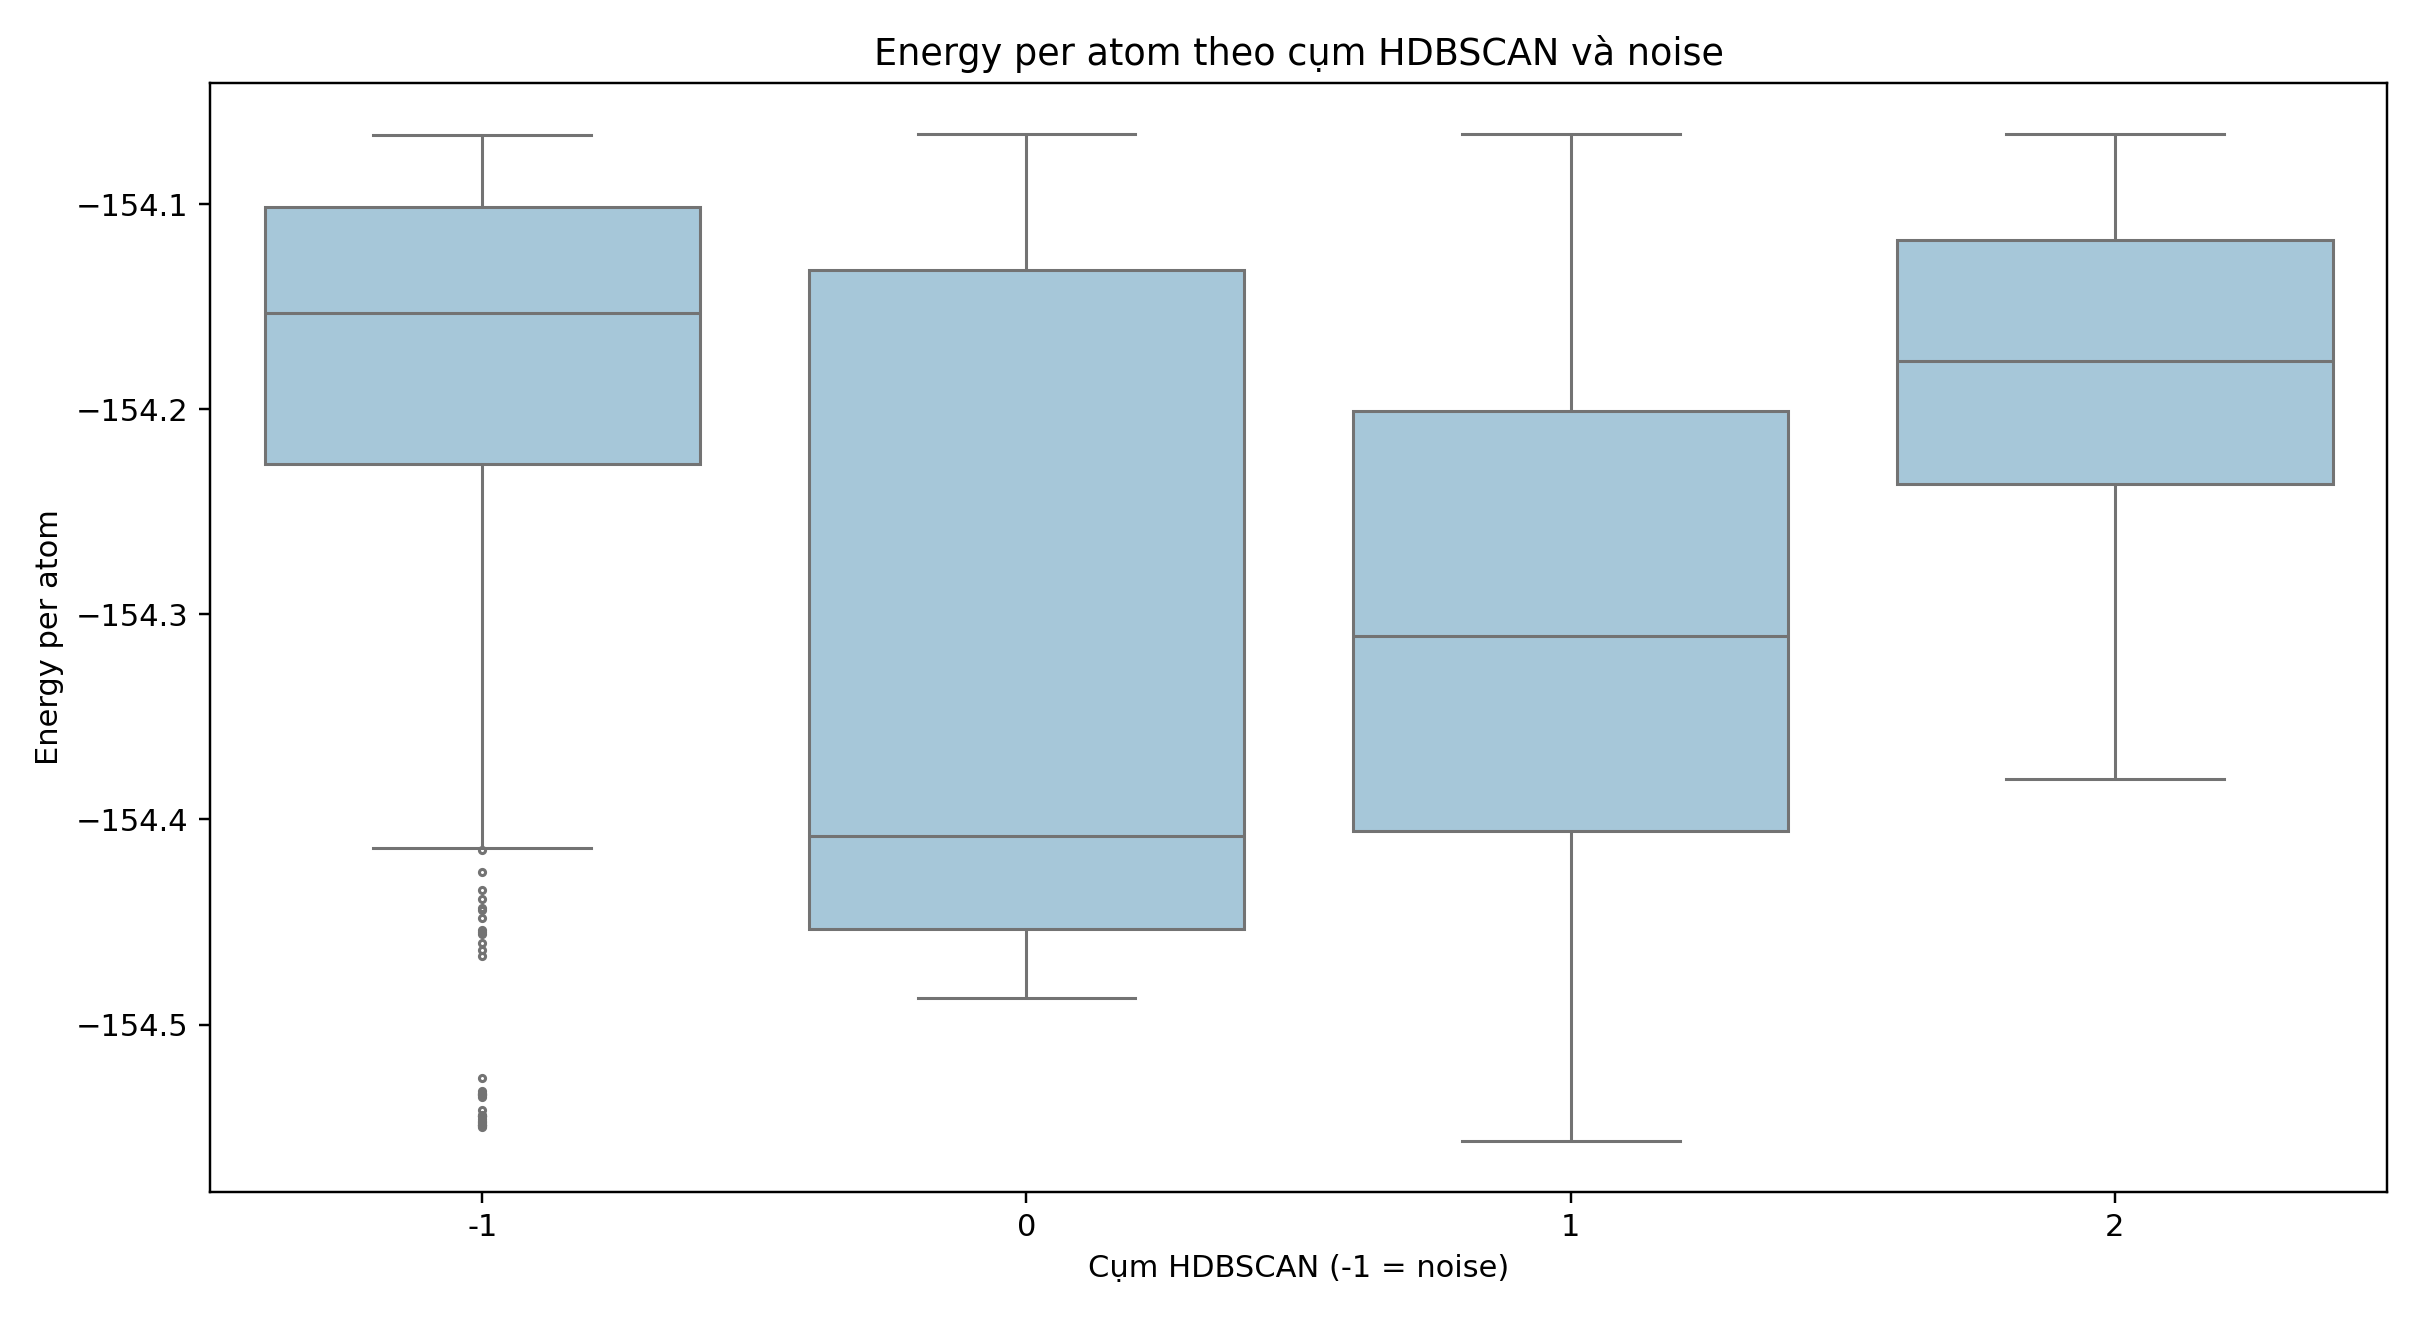

In [16]:
profile_df = pd.read_csv('Combine_Dataset/hdbscan_phuc/hdbscan_cluster_profile.csv')
display(profile_df)
display(Image(filename='Combine_Dataset/hdbscan_phuc/figures/hdbscan_energy_boxplot.png'))

## 9. Diễn giải kết quả và mức độ phù hợp

Phần này tổng hợp lại cấu hình được chọn, số cụm, tỷ lệ noise và profile năng lượng. Đây là phần quan trọng khi viết báo cáo vì HDBSCAN không chỉ tạo cụm mà còn chỉ ra các mẫu không thuộc vùng mật độ ổn định (`label = -1`).

In [17]:
search_df = pd.read_csv("Combine_Dataset/hdbscan_phuc/hdbscan_grid_search.csv")
results_df = pd.read_csv("Combine_Dataset/hdbscan_phuc/hdbscan_results.csv")
profile_df = pd.read_csv("Combine_Dataset/hdbscan_phuc/hdbscan_cluster_profile.csv")
energy_summary_df = pd.read_csv("Combine_Dataset/hdbscan_phuc/hdbscan_energy_summary.csv")

best_config = search_df.loc[search_df["selected_best"]].iloc[0]
noise_ratio = results_df["hdbscan_is_noise"].mean()
n_clusters = results_df.loc[~results_df["hdbscan_is_noise"], "hdbscan_cluster"].nunique()
lowest_energy_cluster = energy_summary_df.loc[
    ~energy_summary_df["is_noise_cluster"]
].sort_values("energy_mean").iloc[0]
highest_energy_cluster = energy_summary_df.loc[
    ~energy_summary_df["is_noise_cluster"]
].sort_values("energy_mean", ascending=False).iloc[0]

display(
    energy_summary_df.sort_values("hdbscan_cluster")[
        [
            "hdbscan_cluster",
            "is_noise_cluster",
            "n_samples",
            "energy_mean",
            "relative_energy_mean",
            "probability_mean",
            "dominant_crystal_system",
            "dominant_space_group_symbol",
        ]
    ]
)

print("Cấu hình HDBSCAN được chọn:")
print(best_config.to_string())
print()
print(f"Số cụm thật sự, không tính noise: {n_clusters}")
print(f"Tỷ lệ noise/outlier: {noise_ratio:.2%}")
print(
    "Cụm có năng lượng trung bình thấp nhất:",
    int(lowest_energy_cluster["hdbscan_cluster"]),
    f"(energy_mean = {lowest_energy_cluster['energy_mean']:.6f})",
)
print(
    "Cụm có năng lượng trung bình cao nhất:",
    int(highest_energy_cluster["hdbscan_cluster"]),
    f"(energy_mean = {highest_energy_cluster['energy_mean']:.6f})",
)
print(
    "Nhận xét:",
    "HDBSCAN phù hợp cho phần này vì vừa tìm được các vùng mật độ chính trong không gian feature cấu trúc,",
    "vừa tách được nhóm noise/outlier để phân tích các cấu trúc bất thường."
)


,hdbscan_cluster,is_noise_cluster,n_samples,energy_mean,relative_energy_mean,probability_mean,dominant_crystal_system,dominant_space_group_symbol
0,-1,True,786,-154.182677,0.374308,0.000000,triclinic,P1
1,0,False,2201,-154.302434,0.254551,0.873813,triclinic,P-1
2,1,False,3250,-154.316697,0.240288,0.976444,monoclinic,C2/m
3,2,False,3916,-154.180043,0.376942,0.945947,monoclinic,C2/m


Cấu hình HDBSCAN được chọn:
n_clusters                         3
n_noise                          786
noise_ratio                 0.077416
silhouette_without_noise    0.278758
min_cluster_size                 100
min_samples                       15
selected_best                   True

Số cụm thật sự, không tính noise: 3
Tỷ lệ noise/outlier: 7.74%
Cụm có năng lượng trung bình thấp nhất: 1 (energy_mean = -154.316697)
Cụm có năng lượng trung bình cao nhất: 2 (energy_mean = -154.180043)
Nhận xét: HDBSCAN phù hợp cho phần này vì vừa tìm được các vùng mật độ chính trong không gian feature cấu trúc, vừa tách được nhóm noise/outlier để phân tích các cấu trúc bất thường.
